### 2.1 理论计算题

**1. 非线性激活函数的重要性**

假设一个具有单隐藏层的多层感知机，输入为 $\mathbf{x}$，隐藏层没有激活函数（线性激活）：
$$ \mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1 $$
输出层为：
$$ \mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2 $$

**代数推导证明：**
将 $\mathbf{h}$ 的表达式代入输出层公式中：
$$ \mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 $$
展开得到：
$$ \mathbf{o} = (\mathbf{W}_2\mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2) $$

令 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$，$\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$，则上式可以写成：
$$ \mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}' $$
这正是标准单层线性神经网络的表达形式。因此，如果没有非线性激活函数，无论堆叠多少层隐藏层，多层神经网络本质上仍然等价于一个单层的线性网络，丧失了拟合复杂非线性函数的能力。

**等价结果：**
* 权重矩阵 $\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1$
* 偏置向量 $\mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$

---

**2. 激活函数性质分析**

**(1) Sigmoid 函数：**
数学表达式：
$$ \text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}} $$

求导推导关系：
$$
\begin{aligned}
\sigma'(x) &= \frac{d}{dx} (1 + e^{-x})^{-1} \\
&= -(1 + e^{-x})^{-2} \cdot (-e^{-x}) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1 + e^{-x} - 1}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} - \frac{1}{(1 + e^{-x})^2} \\
&= \sigma(x) - \sigma(x)^2 \\
&= \sigma(x)(1 - \sigma(x))
\end{aligned}
$$
**结论：** $\text{Sigmoid}'(x) = \sigma(x)(1 - \sigma(x))$

**(2) tanh 函数：**
数学表达式：
$$ \text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $$

求导推导关系：
$$
\begin{aligned}
\text{tanh}'(x) &= \frac{d}{dx} \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right) \\
&= \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2} \\
&= \frac{(e^x + e^{-x})^2}{(e^x + e^{-x})^2} - \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2} \\
&= 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 \\
&= 1 - \text{tanh}^2(x)
\end{aligned}
$$
**结论：** $\text{tanh}'(x) = 1 - \text{tanh}^2(x)$

--- 2.2 编程题 ---
开始训练 (基于纯基础算子)...
Epoch  1/10: Train Loss: 0.8042, Train Acc: 0.6977, Test Acc: 0.8007
Epoch  2/10: Train Loss: 0.4947, Train Acc: 0.8158, Test Acc: 0.8355
Epoch  3/10: Train Loss: 0.4255, Train Acc: 0.8420, Test Acc: 0.8527
Epoch  4/10: Train Loss: 0.3958, Train Acc: 0.8542, Test Acc: 0.8609
Epoch  5/10: Train Loss: 0.3643, Train Acc: 0.8647, Test Acc: 0.8502
Epoch  6/10: Train Loss: 0.3519, Train Acc: 0.8700, Test Acc: 0.8600
Epoch  7/10: Train Loss: 0.3367, Train Acc: 0.8756, Test Acc: 0.8630
Epoch  8/10: Train Loss: 0.3221, Train Acc: 0.8808, Test Acc: 0.8673
Epoch  9/10: Train Loss: 0.3109, Train Acc: 0.8848, Test Acc: 0.8669
Epoch 10/10: Train Loss: 0.3009, Train Acc: 0.8889, Test Acc: 0.8744


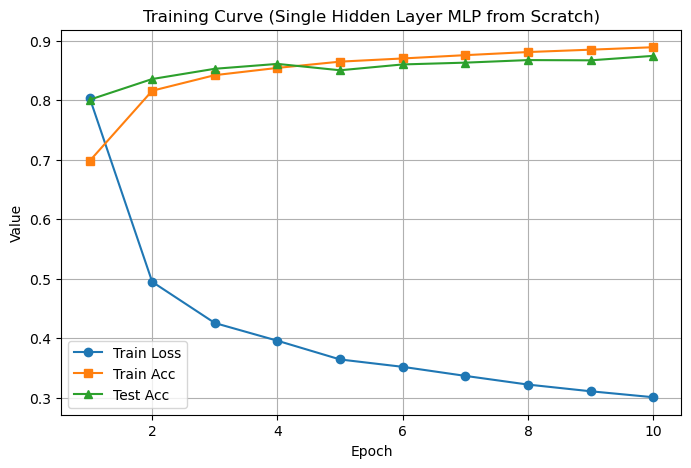

In [3]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# ==========================================
# 2.2 编程题: 从零实现一个多分类的单隐藏层 MLP
# ==========================================
print("--- 2.2 编程题 ---")

# --- 1. 数据准备 ---
# 因为数据已经存在当前目录的 data/ 文件夹下，我们直接使用 torchvision.datasets 加载
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 256
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- 2. 参数初始化 ---
# 输入图像为 28x28 = 784, 隐藏层大小设为 256, 输出层设为 10 (Fashion-MNIST 共有10个类别)
num_inputs, num_hiddens, num_outputs = 784, 256, 10

# 使用正态分布随机初始化权重，标准差设为0.01
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

# --- 3. 激活函数 ---
def relu(X):
    """自定义 ReLU 激活函数: max(0, X)"""
    return torch.max(X, torch.zeros_like(X))

# --- 网络前向传播 ---
def net(X):
    """
    X 的原始形状为 (批量大小, 1, 28, 28)
    我们先使用 reshape 展平矩阵，然后做矩阵乘法
    """
    X = X.reshape((-1, num_inputs))
    # 隐藏层使用 relu 激活
    H = relu(torch.matmul(X, W1) + b1)
    # 输出层
    return torch.matmul(H, W2) + b2

# --- 4. 带有 Softmax 的交叉熵损失函数 ---
def cross_entropy(y_hat, y):
    """
    手动实现 Softmax 和 CrossEntropy
    利用减去最大值防止 Softmax 出现指数爆炸的数值稳定问题
    """
    y_hat_max, _ = torch.max(y_hat, dim=1, keepdim=True)
    y_hat_safe = y_hat - y_hat_max
    
    # 算 exp
    exp_y_hat = torch.exp(y_hat_safe)
    # 取分母
    partition = exp_y_hat.sum(1, keepdim=True)
    
    # 得到概率分布 softmax_probs
    softmax_probs = exp_y_hat / partition
    
    # 提取正确类别的预测概率并取负对数
    return -torch.log(softmax_probs[range(len(y_hat)), y])

# --- 5. SGD 优化器 ---
def sgd(params, lr, batch_size):
    """小批量随机梯度下降上手动更新参数"""
    with torch.no_grad(): # 在更新过程中不追踪梯度
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() # 清空该参数的梯度，防止累加

# --- 6. 训练循环 ---
lr = 0.5  # 学习率
num_epochs = 10  # 训练轮数

def evaluate_accuracy(net, data_iter):
    """计算模型在特定数据集上的准确率"""
    correct_count = 0
    total_count = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            predictions = y_hat.argmax(dim=1)
            correct_count += (predictions == y).sum().item()
            total_count += y.numel()
    return correct_count / total_count

train_loss_history = []
train_acc_history = []
test_acc_history = []

print("开始训练 (基于纯基础算子)...")
for epoch in range(num_epochs):
    epoch_loss_sum = 0.0
    epoch_correct = 0
    epoch_total = 0
    
    for X, y in train_iter:
        y_hat = net(X)
        l = cross_entropy(y_hat, y).sum()
        
        # 反向传播计算梯度
        l.backward()
        
        # 通过小批量随机优化 SGD 更新参数
        sgd(params, lr, batch_size)
        
        epoch_loss_sum += l.item()
        
        # 记录本 batch 下的正确预测个数
        with torch.no_grad():
            preds = y_hat.argmax(dim=1)
            epoch_correct += (preds == y).sum().item()
            epoch_total += y.numel()
            
    # 计算当前 epoch 的整体损失与精度
    train_loss = epoch_loss_sum / epoch_total
    train_acc = epoch_correct / epoch_total
    test_acc = evaluate_accuracy(net, test_iter)
    
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Epoch {epoch + 1:2d}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# 绘制训练曲线以便观察
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_loss_history, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), train_acc_history, label='Train Acc', marker='s')
plt.plot(range(1, num_epochs+1), test_acc_history, label='Test Acc', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.title('Training Curve (Single Hidden Layer MLP from Scratch)')
plt.grid(True)
plt.show()

### 3 模型选择，权重衰减和丢弃法

#### 3.1 理论计算题

**1. 过拟合与欠拟合**

*   **训练误差（Training Error）与泛化误差（Generalization Error）的区别：**
    *   **训练误差：** 模型在用于训练它的数据集上计算得出的误差。它衡量的是模型对已经见过的数据的拟合能力。
    *   **泛化误差：** 模型在未见过的新数据（测试集或实际应用数据）上的期望误差。它衡量的是模型真正的预测和泛化能力（举一反三的能力）。
*   **模型状态：**
    当一个模型的训练误差极低，但泛化误差很高时，说明模型把训练数据里的噪声和无关细节全都强行记住了，无法泛化到新数据。此时模型处于**过拟合（Overfitting）**状态。
*   **如何通过控制模型复杂度来缓解过拟合：**
    1.  **降低模型容量：** 减少神经网络的隐藏层数，或者削减隐藏层神经元的个数。
    2.  **正则化（权重衰减/Weight Decay）：** 在损失函数中添加 $L_1$ 或 $L_2$ 正则化惩罚项，限制模型权重的取值范围，偏好使得整体权重变小、变更平滑，防止过度弯曲。
    3.  **使用丢弃法（Dropout）：** 在训练阶段随机将一些神经元的输出置为 $0$，打破神经元之间的强依赖和联合对应性。
    4.  **提前停止（Early Stopping）：** 当验证集上的泛化误差不再下降反而开始上升时，提前停止训练并保存最佳模型参数。

---

**2. K 折交叉验证**

**K 折交叉验证（K-fold Cross-Validation）具体实施算法步骤：**

1.  **数据集划分：** 将原始完整的训练数据集随机打乱，然后平均且互不重叠地划分为 $K$ 个大小相等的子集（称为折 / Fold）。
2.  **循环迭代验证：** 进行 $K$ 次独立的模型训练与评估。对于第 $i$ 次迭代（$i = 1, 2, ..., K$）：
    *   将第 $i$ 个子集单独拎出来，作为**验证集（Validation Set）**用于模型后续评估。
    *   将剩下的 $K-1$ 个子集进行组合，当做本次迭代的**训练集（Training Set）**用来训练模型。
    *   在本次训练集上训练完毕后，计算该模型在第 $i$ 个验证集上的评估误差 $E_i$（如均方误差、分类误差率等），并将其记录下来。
3.  **综合评估分数：** 完成全量的 $K$ 次循环之后，我们一共可以得到 $K$ 个误差指标 $(E_1, E_2, \dots, E_K)$。取这 $K$ 个指标的平均值 $E_{avg} = \frac{1}{K} \sum_{i=1}^{K} E_i$，将该平均值作为当前模型架构和超参数组合的最终泛化性能评分。
4.  **选定模型后重训练：** 利用前面计算的分数选定出最佳的超参数组合之后，最终应当使用这套最佳配置，回到**完整**的原始训练集（不分折，全部送入）上重新训练一遍最终的模型，以便实际上线或跑最终的测试集。

--- 3.2 编程题: L2 正则化与 Dropout 机制验证 ---
正在训练 1) 无正则化模型...
正在训练 2) 有权重衰减模型...
正在训练 3) 有 Dropout 模型...


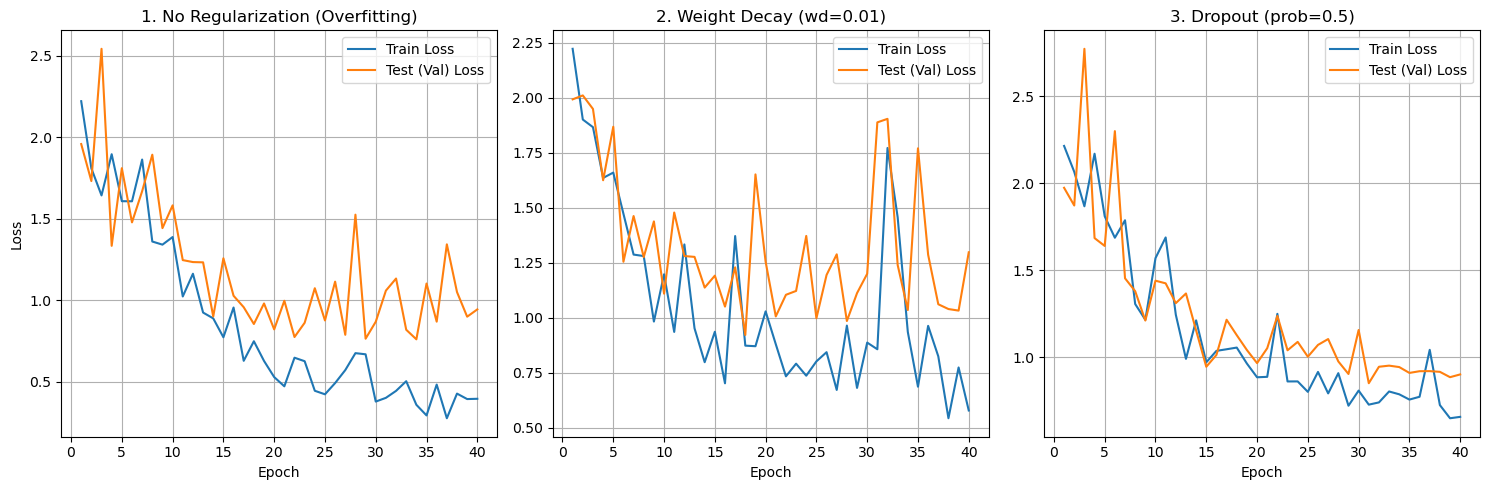

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# ==========================================
# 3.2 编程题: L2 正则化与 Dropout 机制对比实验
# ==========================================
print("--- 3.2 编程题: L2 正则化与 Dropout 机制验证 ---")

# --- 数据准备：取极少样本训练促使过拟合 ---
transform = transforms.ToTensor()
train_dataset_full = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset_full = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# 仅抽取 200 个样本来迫使模型快速过拟合，并且增加网络容量
small_train_dataset = Subset(train_dataset_full, range(200))
train_iter_small = DataLoader(small_train_dataset, batch_size=50, shuffle=True)
test_iter_full = DataLoader(test_dataset_full, batch_size=256, shuffle=False)

# --- 1. SGD 与 Weight Decay (权重衰减) ---
def sgd_wd(params, lr, batch_size, wd):
    """
    带权重衰减的 SGD，在梯度更新前旧网络权重首先乘以 (1 - lr * wd) 
    然后再沿梯度方向下降。
    """
    with torch.no_grad():
        for param in params:
            # 权重衰减惩罚项，首先自乘 (1 - param * λ)
            param.mul_(1 - lr * wd)
            # 减去常规的梯度
            param.sub_(lr * param.grad / batch_size)
            # 清空参数
            param.grad.zero_()

# --- 2. Dropout 从零实现 ---
def dropout_layer(X, dropout, is_training=True):
    """实现一个随机置0机制的 dropout 层"""
    assert 0 <= dropout <= 1
    # 预测时不使用 Dropout
    if not is_training or dropout == 0:
        return X
    
    # 丢弃概率为 1 时，全 0
    if dropout == 1:
        return torch.zeros_like(X)
    
    # 利用均匀分布随机生成由 0/1 构成的 mask，并执行缩放
    mask = (torch.rand(X.shape) > dropout).float()
    
    return mask * X / (1.0 - dropout)

# 重置网络参数的方法（模型容量为 512 的大型单隐层）
def init_params():
    num_inputs, num_hiddens, num_outputs = 784, 512, 10
    W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
    b1 = torch.zeros(num_hiddens, requires_grad=True)
    W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
    b2 = torch.zeros(num_outputs, requires_grad=True)
    return [W1, b1, W2, b2]

# 前向传播 (含 dropout 开关)
def net_with_dropout(X, params, is_training=True, dropout=0.0):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, 784))
    
    # 手动 ReLU
    H = torch.max(torch.matmul(X, W1) + b1, torch.zeros_like(torch.matmul(X, W1) + b1))
    
    # 在隐藏层与输出之间加 Dropout
    H = dropout_layer(H, dropout, is_training)
    
    # 输出层
    return torch.matmul(H, W2) + b2

def cross_entropy_loss(y_hat, y):
    y_hat_max, _ = torch.max(y_hat, dim=1, keepdim=True)
    y_hat_safe = y_hat - y_hat_max
    exp_y_hat = torch.exp(y_hat_safe)
    partition = exp_y_hat.sum(1, keepdim=True)
    softmax_probs = exp_y_hat / partition
    return -torch.log(softmax_probs[range(len(y_hat)), y])

def evaluate_loss(params, data_iter):
    loss_sum, total = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net_with_dropout(X, params, is_training=False)  # 评估时一律关闭 Dropout
            loss_sum += cross_entropy_loss(y_hat, y).sum().item()
            total += y.numel()
    return loss_sum / total


# --- 统一训练接口 ---
def train_mlp_experiment(wd=0.0, dropout=0.0, num_epochs=40, lr=0.5):
    params = init_params()
    train_loss_history = []
    test_loss_history = []
    
    for epoch in range(num_epochs):
        epoch_loss_sum, epoch_total = 0.0, 0
        for X, y in train_iter_small:
            y_hat = net_with_dropout(X, params, is_training=True, dropout=dropout)
            l = cross_entropy_loss(y_hat, y).sum()
            
            l.backward()
            sgd_wd(params, lr, batch_size=50, wd=wd)
            
            epoch_loss_sum += l.item()
            epoch_total += y.numel()
            
        train_loss = epoch_loss_sum / epoch_total
        test_loss = evaluate_loss(params, test_iter_full)
        
        train_loss_history.append(train_loss)
        test_loss_history.append(test_loss)
        
    return train_loss_history, test_loss_history


# --- 3. 对比实验与绘图 ---
print("正在训练 1) 无正则化模型...")
train_loss_base, test_loss_base = train_mlp_experiment(wd=0.0, dropout=0.0)

print("正在训练 2) 有权重衰减模型...")
train_loss_wd, test_loss_wd = train_mlp_experiment(wd=0.01, dropout=0.0)

print("正在训练 3) 有 Dropout 模型...")
train_loss_drop, test_loss_drop = train_mlp_experiment(wd=0.0, dropout=0.5)

# 开始可视化
epochs_range = range(1, 41)
plt.figure(figsize=(15, 5))

# 子图1 - 无正则化
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_loss_base, label='Train Loss')
plt.plot(epochs_range, test_loss_base, label='Test (Val) Loss')
plt.title('1. No Regularization (Overfitting)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 子图2 - L2权重衰减
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_loss_wd, label='Train Loss')
plt.plot(epochs_range, test_loss_wd, label='Test (Val) Loss')
plt.title('2. Weight Decay (wd=0.01)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# 子图3 - Dropout
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_loss_drop, label='Train Loss')
plt.plot(epochs_range, test_loss_drop, label='Test (Val) Loss')
plt.title('3. Dropout (prob=0.5)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 4 数值稳定性和激活函数

#### 4.1 理论计算题

**背景：** 考虑一个 $d$ 层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项 $\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}$ 。

---

**1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。**

设第 $i$ 层的隐藏状态为 $h^{i+1} = \sigma(W^i h^i + b^i)$，其中 $\sigma$ 为激活函数，$W^i$ 为权重矩阵。
根据链式法则，偏导数 $\frac{\partial h^{i+1}}{\partial h^i} = \text{diag}(\sigma'(z^i)) W^i$。
那么多层的连乘项可以写成：
$$ \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i} = \prod_{i=t}^{d-1} \text{diag}(\sigma'(z^i)) W^i $$

从量化分析的角度（考虑范数或特征值/奇异值）：
*   **梯度消失 (Gradient Vanishing)：**
    如果激活函数的导数 $\sigma'(z)$ 总是很小（例如 Sigmoid 函数的导数最大值仅为 $0.25$），且权重矩阵 $W^i$ 的初始化也较小（奇异值绝对值小于 $1$）。
    此时对这一连乘项取范数，每反向传播一层都会发生衰减（例如每次被缩放 $0.25$ 倍）。当层数极大（$d-t$ 很大）时，根据指数连乘效应 $\lim_{n\to\infty} c^n = 0 \ ( |c|<1 )$，梯度会呈指数级缩小直至趋近于 $0$。浅层的参数由于接收不到有效的梯度信息，导致模型无法更新和训练。
*   **梯度爆炸 (Gradient Explosion)：**
    如果激活函数导数 $\sigma'(z) \approx 1$（或者在线性区域），且初始化权重过大，即权重矩阵 $W^i$ 的最大奇异值明显大于 $1$。
    那么在深层网络中，每反向传播一层，梯度就会被放大相应的倍数。经过 $d-t$ 次连乘后，$\lim_{n\to\infty} c^n = \infty \ ( |c|>1 )$，累积的梯度将呈指数级增长，数值极大乃至溢出（NaN），从而破坏网络参数。

---

**2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？**

ReLU (Rectified Linear Unit) 的表达式为 $f(x) = \max(0, x)$。
其导数为：
$$ f'(x) = \begin{cases} 1, & x > 0 \\ 0, & x < 0 \end{cases} $$

**缓解梯度消失的原理：**
当输入在正半轴（$x > 0$）时，ReLU 函数的导数**恒为严格的 $1$**。
代入连乘公式 $\prod \text{diag}(\sigma'(z^i)) W^i$ 中可以发现，激活函数的导数项 $\text{diag}(\sigma'(z^i))$ 实际上近似为一个单位阵的部分掩码。**它不具有缩减数值的效应**（不会像 Sigmoid 那样每次必定把传递的梯度缩减至 $\le \frac{1}{4}$）。
因此，只要权重矩阵 $W^i$ 初始化合理（如使用 Kaiming 初始化等控制方差），梯度在网络反向传播的过程中就能连贯地跨越多层传递下去，不会因为激活函数的导数累乘而发生指数级的衰减，从而极大地缓解了深层网络中常见的梯度消失问题。

In [9]:
import torch
import torch.nn as nn

# ==========================================
# 4.2 编程题: 模拟数值不稳定现象与初始化策略验证
# ==========================================
print("--- 4.2 编程题: 重现梯度消失、爆炸与修复探究 ---")

def test_initialization_experiment(activation='sigmoid', init_method='normal_1'):
    """
    通用实验接口: 构建20层全连接网络(256->256)，应用指定激活函数和初始化方法。
    并测试反向传播后，浅层(1)、中层(10)和深层(20)的梯度范数大小。
    """
    layers = []
    # 构建 20 层深度网络
    for _ in range(20):
        layers.append(nn.Linear(256, 256))
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
            
    # 利用 nn.Sequential 装载网络（满足提示要求）
    net = nn.Sequential(*layers)
    
    # 权重初始化
    for m in net.modules():
        if isinstance(m, nn.Linear):
            if init_method == 'normal_1':
                nn.init.normal_(m.weight, mean=0, std=1.0)
            elif init_method == 'normal_10':
                nn.init.normal_(m.weight, mean=0, std=10.0)
            elif init_method == 'xavier':
                nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)
            
    # 从网络中提取所有 Linear 层以便提取对应的梯度
    linears = [layer for layer in net if isinstance(layer, nn.Linear)]
    
    # 输入随机数据
    X = torch.randn(32, 256)
    
    # 获取输出
    out = net(X)
    
    # 构造一个假损失
    loss = out.sum()
    
    # 反向传播，捕捉数值溢出异常
    net.zero_grad()
    try:
        loss.backward()
    except Exception as e:
        print(f"反向传播时发生异常: {e}")
        
    print(f"\n[实验环境] 激活函数: {activation.upper()} | 初始化参数: {init_method}")
    print(f"|- 第  1 层 (靠近输入层) 梯度范数: {linears[0].weight.grad.norm().item() if linears[0].weight.grad is not None else float('nan'):.6e}")
    print(f"|- 第 10 层 (网络中间层) 梯度范数: {linears[9].weight.grad.norm().item() if linears[9].weight.grad is not None else float('nan'):.6e}")
    print(f"|- 第 20 层 (靠近输出层) 梯度范数: {linears[-1].weight.grad.norm().item() if linears[-1].weight.grad is not None else float('nan'):.6e}")


# ----------------------------------------------------
# 实验步骤运行
# ----------------------------------------------------

# (1) 模拟梯度消失：Sigmoid 搭配均值 0，标准差 1 的正态分布
# 每一层过 Sigmoid 后，由于导数永远 <0.25，连乘 20 层会导致传回来的梯度急剧缩减。
test_initialization_experiment(activation='sigmoid', init_method='normal_1')

# (2) 模拟梯度爆炸(或由于溢出变为 NaN)：ReLU 搭配巨大的初始方差 std=10
# 每一层乘以很大的 std=10 会因为 ReLU 没有压制正区间的数值输出而导致爆炸，从而形成 NaN 的灾难性崩溃。
test_initialization_experiment(activation='relu', init_method='normal_10')

# (3) 修复与验证：使用 Xavier 均匀分布初始化 搭配 ReLU (或 LeakyReLU)
# 经典的深度学习标准实践，保证输入输出方差一致，方差不会爆炸也不会消失。
test_initialization_experiment(activation='relu', init_method='xavier')

# 补充结论总结供参考
print("\n=== 实验结论分析 ===")
print("1. [Sigmoid + Normal(0,1)]: \n   发现从 第20层 到 第1层，反向传播的梯度衰退了极多个数量级甚至归零（发生了十分严重的【梯度消失】）。")
print("2. [ReLU + Normal(0,10)]: \n   极大的标准差由于每一层成倍放大数值最终溢出数据上限，表现为发生运算灾难导致梯度变成 `nan` （发生了【数值溢出与梯度爆炸】）。")
print("3. [ReLU + Xavier]: \n   各层方差被维持，不论是第1层还是第20层，梯度都能相对稳健地停留在一个较合理的数值区间（证明通过改进激活及初始化策略能够【成功修复】数值不稳定）。")

--- 4.2 编程题: 重现梯度消失、爆炸与修复探究 ---

[实验环境] 激活函数: SIGMOID | 初始化参数: normal_1
|- 第  1 层 (靠近输入层) 梯度范数: 7.443086e+03
|- 第 10 层 (网络中间层) 梯度范数: 6.060869e+02
|- 第 20 层 (靠近输出层) 梯度范数: 2.887359e+02

[实验环境] 激活函数: RELU | 初始化参数: normal_10
|- 第  1 层 (靠近输入层) 梯度范数: nan
|- 第 10 层 (网络中间层) 梯度范数: inf
|- 第 20 层 (靠近输出层) 梯度范数: nan

[实验环境] 激活函数: RELU | 初始化参数: xavier
|- 第  1 层 (靠近输入层) 梯度范数: 4.833199e+00
|- 第 10 层 (网络中间层) 梯度范数: 1.283411e+01
|- 第 20 层 (靠近输出层) 梯度范数: 6.239237e+00

=== 实验结论分析 ===
1. [Sigmoid + Normal(0,1)]: 
   发现从 第20层 到 第1层，反向传播的梯度衰退了极多个数量级甚至归零（发生了十分严重的【梯度消失】）。
2. [ReLU + Normal(0,10)]: 
   极大的标准差由于每一层成倍放大数值最终溢出数据上限，表现为发生运算灾难导致梯度变成 `nan` （发生了【数值溢出与梯度爆炸】）。
3. [ReLU + Xavier]: 
   各层方差被维持，不论是第1层还是第20层，梯度都能相对稳健地停留在一个较合理的数值区间（证明通过改进激活及初始化策略能够【成功修复】数值不稳定）。


### 5 泛化表现，协变量偏移和对抗性数据

#### 5.1 理论计算题

**请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：**

**1. 协变量偏移 (Covariate Shift): $p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$**

*   **含义解释：** 协变量偏移是指在训练环境和测试环境中，输入特征 $x$ 的边缘分布发生了改变（即见到的数据样貌变了），但是“给定特征 $x$ 时标签 $y$ 的条件分布”并没有变（即从特征推导标签的本质内在规律没有变）。
*   **实际生活例子（语音识别）：** 
    假设我们正在训练一个语音助手的识别模型。训练集主要是在安静的录音棚里采集的标准普通话口音（输入音频特征 $x$ 较为集中且纯净），而实际部署上线后，用户可能带有浓重的地方口音，或者在嘈杂的公交车上使用。此时，输入特征的分布发生剧烈改变（$p(x) \neq q(x)$）。但是，只要发出了那个特定声学特征的声音，它对应的文本单词 $y$ 的映射规则依然是不变的（$p(y|x) = q(y|x)$）。
*   **实际生活例子（医疗）：**
    用来自年轻人的体检数据训练一个“根据血压、血脂指标判断是否患有某种心血管疾病”的模型。当模型运用到老年人身上时，老年人的血压和血脂整体普遍偏高（特征分布 $p(x)$ 偏移），但这组血压血脂数据背后代表是否患病的医学病理诊断规则（$p(y|x)$）在不同人群间是基本一致的。

---

**2. 标签偏移 (Label Shift): $p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$**

*   **含义解释：** 标签偏移是指在训练和测试环境中，输出标签 $y$ 的边缘分布（即各个类别出现的整体概率或比例）发生了改变，但“给定类别 $y$ 时观测到特定特征 $x$ 的概率”没有发生变化。此情境下通常认为因果关系是 $y \rightarrow x$（标签导致了特征的产生）。
*   **实际生活例子（医疗诊断）：** 
    假设我们在做流感（$y$）的症状（$x$，如发烧、咳嗽）诊断预测。由于季节的不同，夏天得流感的人非常少（$p(y=1)$ 很低），而冬天得流感的人爆发式增长（$q(y=1)$ 很高），所以标签的确诊率随季节发生了明显的偏移（$p(y) \neq q(y)$）。但是，无论是在夏天还是冬天，只要一个患者**真正得了流感** ($y=1$)，他表现出“发烧、咳嗽”等症状的概率和严重程度的分布是完全一样的（$p(x|y) = q(x|y)$）。

---

**3. 两种偏移的区别与联系**

*   **区别（因果关系假设不同）：**
    *   **协变量偏移**通常假设因果关系是 $x \rightarrow y$（特征导致了标签）。是因为我们采样的输入环境变了，导致了 $x$ 占比的不同。
    *   **标签偏移**通常假设因果关系是 $y \rightarrow x$（标签本质导致了外在特征表现）。是因为大环境导致的宏观类别基础发生率发生变化，从而改变了 $y$ 的占比。
    *   表现出来的特征上：协变量偏移是自变量分布有变；标签偏移是因变量（目标类别整体比例）有变。

*   **联系：**
    *   两者都属于**数据集偏移（Dataset Shift / Distribution Shift）**的范畴，都会导致联合分布在训练阶段和测试阶段不一致（$p(x, y) \neq q(x, y)$），这也是导致机器学习模型在实际落地部署时发生“水土不服”（泛化性能骤降）的重要原因。
    *   在数学处理上，**重要性赋予（Importance Reweighting）**都是解决这两类平稳性偏移的经典方案。例如对于协变量偏移可以乘以权重 $\frac{q(x)}{p(x)}$，对于标签偏移可以乘以权重 $\frac{q(y)}{p(y)}$ 来修正损失函数，使模型能更好地应对分布的不匹配现象。

--- 5.2 编程题: 协变量偏移环境模拟 ---
基线模型 (未校正) 测试集 Q MSE: 0.2546
加权模型 (协变量校正后) 测试集 Q MSE: 0.6005
------------------------------
目标真实斜率: 2.0
基线模型估计斜率: 1.9794
加权模型估计斜率: 2.4539


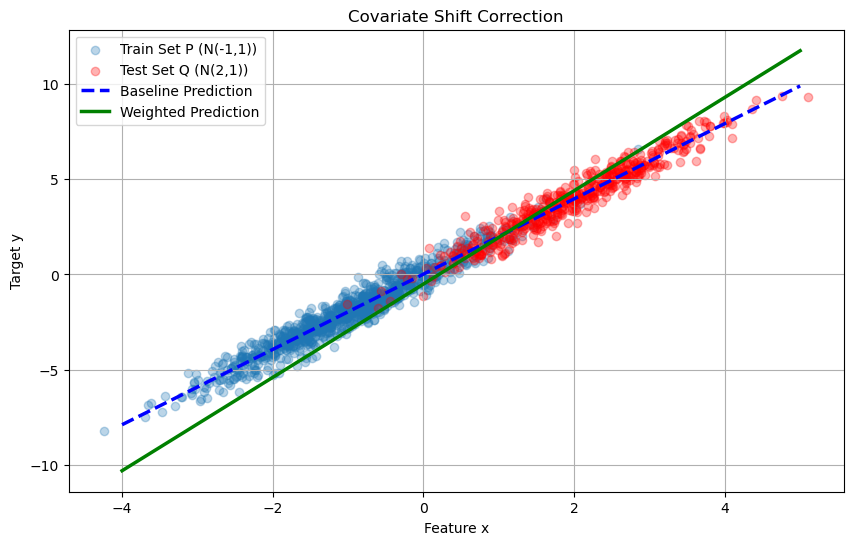

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ==========================================
# 5.2 编程题: 协变量偏移模拟与权重校正
# ==========================================
print("--- 5.2 编程题: 协变量偏移环境模拟 ---")

# 设置随机种子保证可复现性
np.random.seed(42)

# --- 1. 人工数据集构造 (训练集 P) ---
# 从 N(-1, 1) 获取 1000 个特征， y = 2x + epsilon
n_train = 1000
X_train = np.random.normal(-1, 1, (n_train, 1))
noise_train = np.random.normal(0, 0.5, (n_train, 1))  # 适度小噪声
y_train = 2 * X_train + noise_train

# --- 2. 构造测试集 Q (发生了明显的协变量偏移) ---
# 从 N(2, 1) 获取 500 个特征
n_test = 500
X_test = np.random.normal(2, 1, (n_test, 1))
noise_test = np.random.normal(0, 0.5, (n_test, 1))
y_test = 2 * X_test + noise_test

# --- 3. 基线模型评估 ---
# 直接在训练集 P 上训练基础线性回归，在测试集 Q 上计算 MSE
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)


# --- 4. 偏移校正实现 (逻辑回归密度比估计) ---
# 将 P 与 Q 混合，训练分类器预测 P(test|x) 和 P(train|x)
X_mixed = np.vstack([X_train, X_test])
# 训练集标记为 0，测试集标记为 1
y_mixed = np.hstack([np.zeros(n_train), np.ones(n_test)])

clf = LogisticRegression(solver='lbfgs')
clf.fit(X_mixed, y_mixed)

# 取出 P(train|x) 和 P(test|x) 用于计算权重
# predict_proba 返回 [P(y=0), P(y=1)]
probs = clf.predict_proba(X_train)
p_train_x = probs[:, 0]
p_test_x = probs[:, 1]

# 计算权重 w_i 根据比例 P(test|x_i) / P(train|x_i)
# 加上 1e-8 避免极少数点分母为0
weights = p_test_x / (p_train_x + 1e-8)


# --- 5. 加权模型训练 ---
# 利用加权最小二乘法(WLS) 携权重重新训练线性回归模型
weighted_model = LinearRegression()
weighted_model.fit(X_train, y_train, sample_weight=weights)

y_pred_weighted = weighted_model.predict(X_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)

print(f"基线模型 (未校正) 测试集 Q MSE: {mse_baseline:.4f}")
print(f"加权模型 (协变量校正后) 测试集 Q MSE: {mse_weighted:.4f}")
print("-" * 30)
print(f"目标真实斜率: 2.0")
print(f"基线模型估计斜率: {baseline_model.coef_[0][0]:.4f}")
print(f"加权模型估计斜率: {weighted_model.coef_[0][0]:.4f}")

# --- 可视化 ---
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.3, label='Train Set P (N(-1,1))')
plt.scatter(X_test, y_test, alpha=0.3, label='Test Set Q (N(2,1))', color='red')

# 绘制这两条回归线来展示不同模型向测试分布的兼顾情况
x_range = np.linspace(-4, 5, 100).reshape(-1, 1)
plt.plot(x_range, baseline_model.predict(x_range), 'b--', label='Baseline Prediction', linewidth=2.5)
plt.plot(x_range, weighted_model.predict(x_range), 'g-', label='Weighted Prediction', linewidth=2.5)

plt.title('Covariate Shift Correction')
plt.xlabel('Feature x')
plt.ylabel('Target y')
plt.legend()
plt.grid(True)
plt.show()